<a href="https://colab.research.google.com/github/qgjoinlayo/EMTECH-1---CPE018/blob/main/INLAYO_Activity_5_Line_and_Circle_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024
<hr> | <hr>
<u>**Activity 4.1** | **Line and Circle Detection**
**Name** | INLAYO, GABRIEL JAN O
**Section** | CPE31S2
**Date Performed**: | 20/01/2026
**Date Submitted**: | 20/01/2026
**Instructor**: | ENGR. SAYO
<hr>

## 1. Objectives

This activity aims to introduce students to openCV's APIs for Hough Transform.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize openCV for circle and line detection.
* Analyze the use of hough Line and Circle function for finding objects in an image.

## 3. Procedures and Outputs

Detecting edges and contours are not only common and important tasks, they also constitute the basis for other complex operations. Lines and shape detection go hand in hand with edge and contour detection, so let's examine how OpenCV implements these.

### Line Detection

The theory behind lines and shape detection has its foundation in a technique called the Hough transform, invented by Richard Duda and Peter Hart, who extended (generalized) the work done by Paul Hough in the early 1960s.

Let's take a look at OpenCV's API for the Hough transforms.

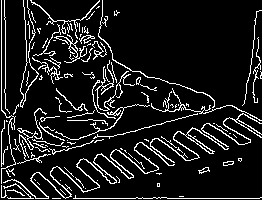

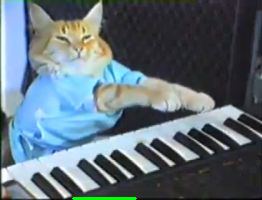

In [ ]:
# Image source: https://en.wikipedia.org/wiki/Keyboard_Cat

from google.colab.patches import cv2_imshow
import cv2
import numpy as np

img = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Keyboard_cat.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,120)
minLineLength = 20
maxLineGap = 5
lines = cv2.HoughLinesP(edges,1,np.pi/180,100,minLineLength,
        maxLineGap)
for x1,y1,x2,y2 in lines[0]:
  cv2.line(img,(x1,y1),(x2,y2),(0,255,0),2)

cv2_imshow(edges)
cv2_imshow(img)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The crucial point of this simple script —aside from the HoughLines function call— is the setting of minimum line length (shorter lines will be discarded) and the maximum line gap, which is the maximum size of a gap in a line before the two segments start being considered as separate lines.

Also note that the HoughLines function takes a single channel binary image, processed through the Canny edge detection filter. Canny is not a strict requirement, however; an image that's been denoised and only represents edges, is the ideal source for a Hough transform, so you will find this to be a common practice.

The parameters of HoughLinesP are as follows:
- The image we want to process.
- The geometrical representations of the lines, rho and theta, which are usually 1 and np.pi/180.
- The threshold, which represents the threshold below which a line is discarded. The Hough transform works with a system of bins and votes, with each bin representing a line, so any line with a minimum of the <threshold> votes is retained, the rest discarded.
- MinLineLength and MaxLineGap, which we mentioned previously

**Questions:**

1. Which line of code is responsible for setting the minimum line length?
2. What is the mathematical formula for Hough transform and explain how it finds lines.

**Answer**

1. The line of code minLineLength = 20 sets the minimum line length.
It ensures that only lines longer than 20 pixels are considered valid detections.

2. The formula is 𝜌 =𝑥 ⋅ cos⁡(𝜃)+𝑦⋅sin⁡(𝜃).
It works by mapping edge points into polar space, where intersections of many votes reveal the presence of a line.


### Circle Detection

OpenCV also has a function for detecting circles, called HoughCircles. It works in a very similar fashion to HoughLines, but where minLineLength and maxLineGap were the parameters to discard or retain lines, HoughCircles has a minimum distance between circles' centers, minimum, and maximum radius of the circles. Here's the obligatory example:

Before going into the sample code, check first: **What is the HoughCircles function and what are its parameters?**

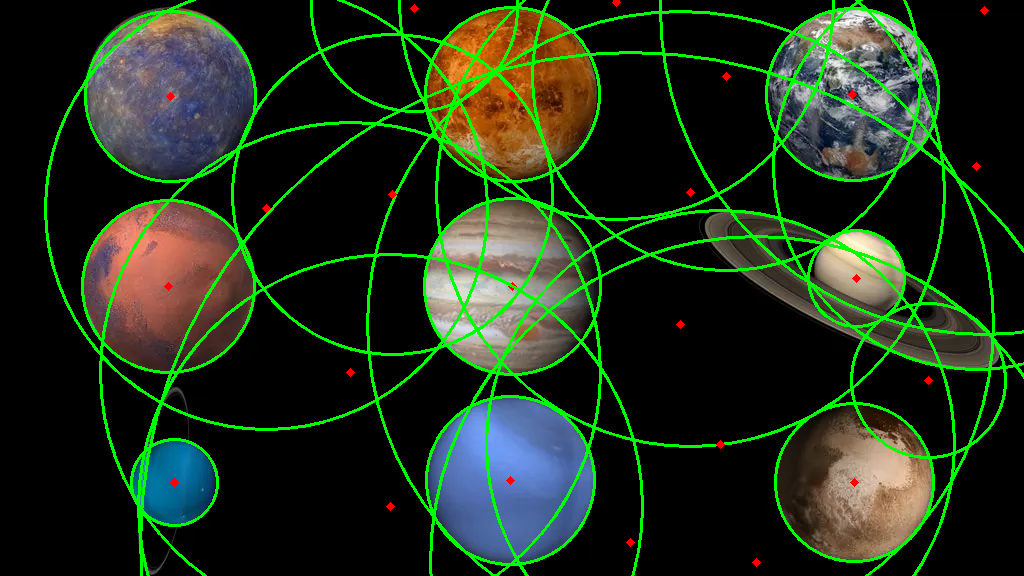

In [ ]:
import cv2
import numpy as np

# Our testing value
n = 5

planets = cv2.imread('/content/drive/MyDrive/ColabNotebooks/planets3x3-pluto-colormercury-axis-tilt-nolabels-1080p.00001-print.webp')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n) # We will change this value passed as parameter and observe results
cimg = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
circles = cv2.HoughCircles(img,cv2.HOUGH_GRADIENT,1,120,
                            param1=100,param2=30,minRadius=0,
                                maxRadius=0)
circles = np.uint16(np.around(circles))

for i in circles[0,:]:
  # draw the outer circle
  cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
  # draw the center of the circle
  cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)

cv2.imwrite("/content/drive/MyDrive/ColabNotebooks/planets3x3-pluto-colormercury-axis-tilt-nolabels-1080p.00001-print.webp", planets)
cv2_imshow(planets)

What happens to the code once you run **and the value of n is 5**?

**ANSWER:**

With n = 5, the median blur slightly smooths the image while preserving most edges. This results in a decent number of circles being detected with clear boundaries.

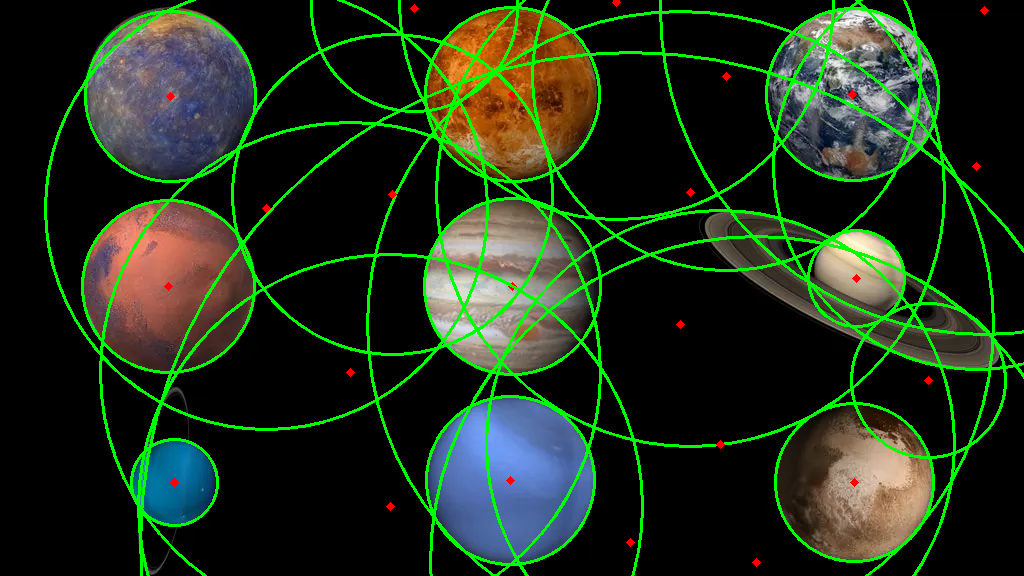

In [ ]:
from google.colab.patches import cv2_imshow
n = 5
planets = cv2.imread('/content/drive/MyDrive/ColabNotebooks/planets3x3-pluto-colormercury-axis-tilt-nolabels-1080p.00001-print.webp')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n)

circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 120,
                           param1=100, param2=30, minRadius=30, maxRadius=100)
cv2_imshow(planets)



Change the value to 9, **what happens to the image**?
**ASNWER:**

Increasing n to 9 applies stronger blurring, which reduces noise but also softens edges. Fewer circles may be detected, and some smaller or faint ones might be missed.

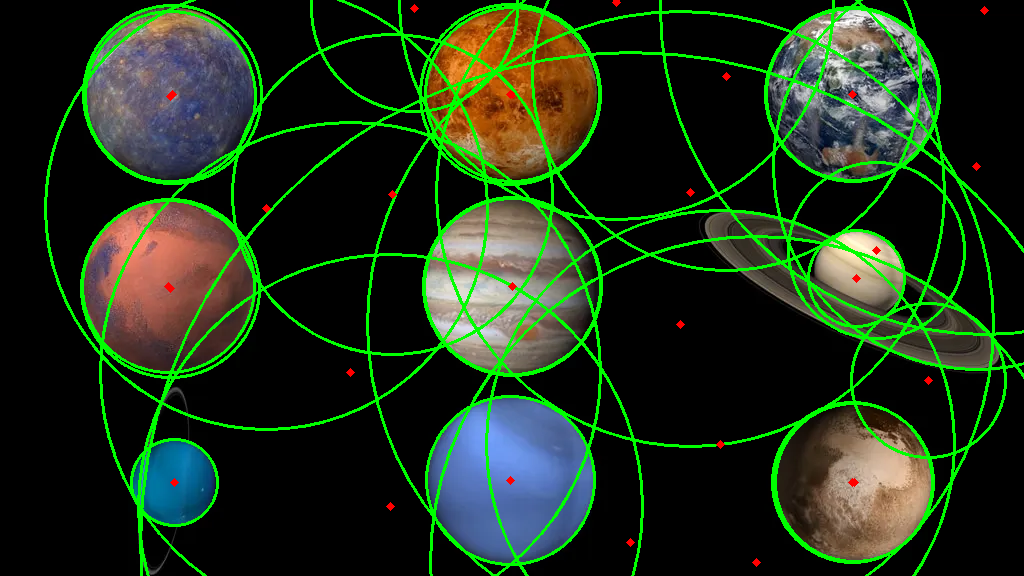

In [ ]:
from google.colab.patches import cv2_imshow
import numpy as np
import cv2

n = 9

gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n)

circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 120,
                           param1=100, param2=30, minRadius=30, maxRadius=100)

circles = np.uint16(np.around(circles))
for i in circles[0,:]:
    cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
    cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)

cv2_imshow(planets)



Lastly, change the value to 15, **what can you say about the resulting image?**
**ANSWER:**

At n = 15, the image becomes heavily blurred, making edges less distinct. This can cause the Hough Circle Transform to miss many circles or detect them inaccurately.

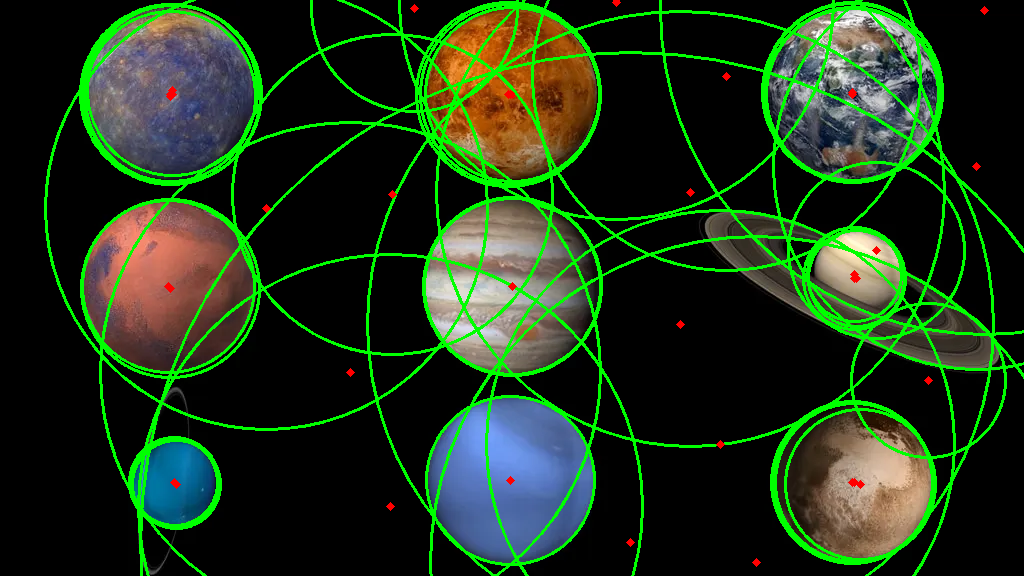

In [ ]:
from google.colab.patches import cv2_imshow
import numpy as np
import cv2

n = 15

gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n)

circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 120,
                           param1=100, param2=30, minRadius=30, maxRadius=100)

circles = np.uint16(np.around(circles))
for i in circles[0,:]:
    cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
    cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)


cv2_imshow(planets)


Provide an analysis of the output so far. How does the code help the changes in the resulting image?

## 4. Supplementary Activity

The attached image contains coins used in the Philippines.

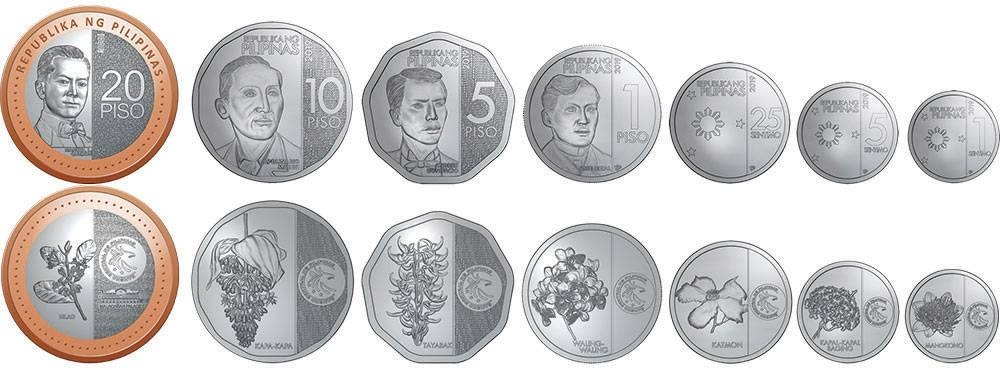

Your job is to count the amount of coins (denomation not included, no sum of prices; just the amount of coins present) through either line detection or circle detection.

- Create a function using line detection and pass this image as parameter, what is the output? Can you use houghlines to count circles?
- Create a function using circle detection and pass this image as parameter, show the output? Can you use houghcircles to count the circles?

In [ ]:
image_path = '/content/drive/MyDrive/ColabNotebooks/COINS.jpg'



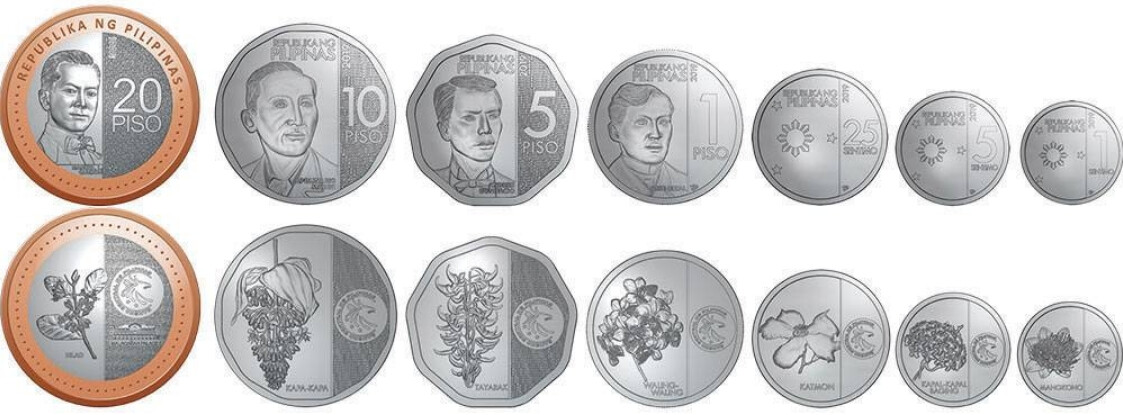

In [ ]:
img = cv2.imread(image_path)
if img is None:
    print("Image not found or path is incorrect.")
else:
    from google.colab.patches import cv2_imshow
    cv2_imshow(img)


1. Line Detection Function (using HoughLines)

In [ ]:
def count_with_line_detection(image_path):
    import cv2
    import numpy as np
    from google.colab.patches import cv2_imshow
    import matplotlib.pyplot as plt

    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print("Image not found or path is incorrect:", image_path)
        return

    # Preprocess
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 80, 180, apertureSize=3)

    # HoughLines (for lines, not circles)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 120)
    line_count = 0

    # Draw lines for visualization
    if lines is not None:
        for line in lines:
            rho, theta = line[0]
            a = np.cos(theta); b = np.sin(theta)
            x0 = a * rho; y0 = b * rho
            x1 = int(x0 + 1000 * (-b)); y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b)); y2 = int(y0 - 1000 * (a))
            cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        line_count = lines.shape[0]

    print(f"Lines detected (visualization only, not coin count): {line_count}")

    # Show outputs (Colab + fallback)
    try:
        cv2_imshow(edges)
        cv2_imshow(img)
    except Exception:
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1); plt.title("Edges"); plt.imshow(edges, cmap='gray'); plt.axis('off')
        plt.subplot(1,2,2); plt.title("Lines overlay"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off')
        plt.show()




2. Circle Detection Function (using HoughCircles)

Now that both functions are defined, you can run the cell below to execute them and see the results:

In [ ]:
def count_with_circle_detection(image_path):
    import cv2
    import numpy as np
    from google.colab.patches import cv2_imshow
    import matplotlib.pyplot as plt

    # Load image
    original = cv2.imread(image_path)
    if original is None:
        print("Image not found or path is incorrect:", image_path)
        return

    # Preprocess
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 7)

    # HoughCircles (tune minDist, param2, radius range for your image)
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT,
        dp=1.2, minDist=60,
        param1=120, param2=28,
        minRadius=35, maxRadius=120
    )

    annotated = original.copy()
    coin_count = 0

    if circles is not None:
        circles = np.uint16(np.around(circles))
        for x, y, r in circles[0, :]:
            cv2.circle(annotated, (x, y), r, (0, 255, 0), 3)
            cv2.circle(annotated, (x, y), 3, (0, 0, 255), 3)
        coin_count = circles.shape[1]

    print(f"Coins detected (HoughCircles): {coin_count}")

    # Show outputs (Colab + fallback)
    try:
        cv2_imshow(blurred)       # preprocessed
        cv2_imshow(annotated)     # result
    except Exception:
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1); plt.title("Blurred (preprocess)"); plt.imshow(blurred, cmap='gray'); plt.axis('off')
        plt.subplot(1,2,2); plt.title("Detected coins"); plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)); plt.axis('off')
        plt.show()


**OUTPUT OF SUPPLEMENTARY:**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Lines detected (visualization only, not coin count): 2779


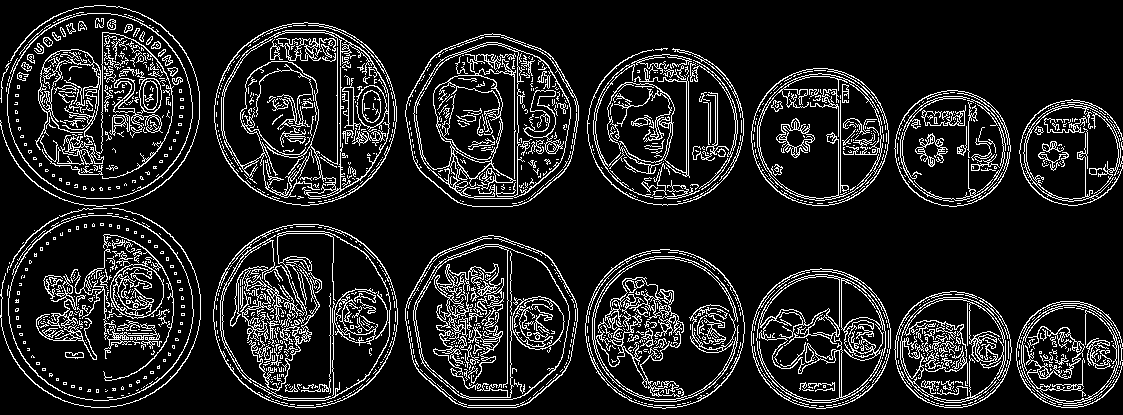

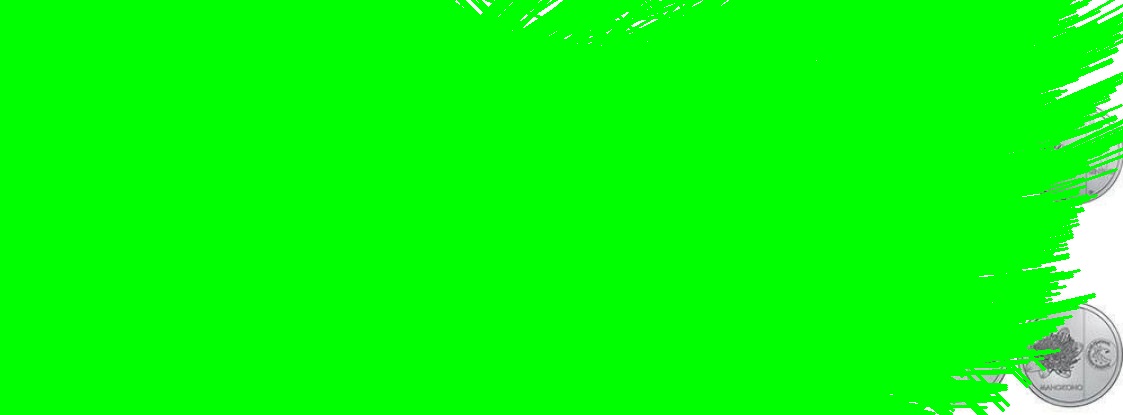

Coins detected (HoughCircles): 29


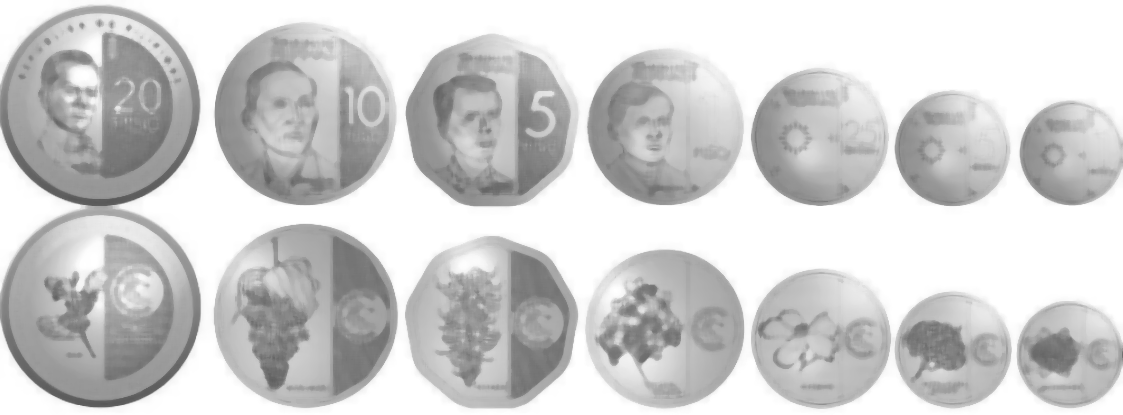

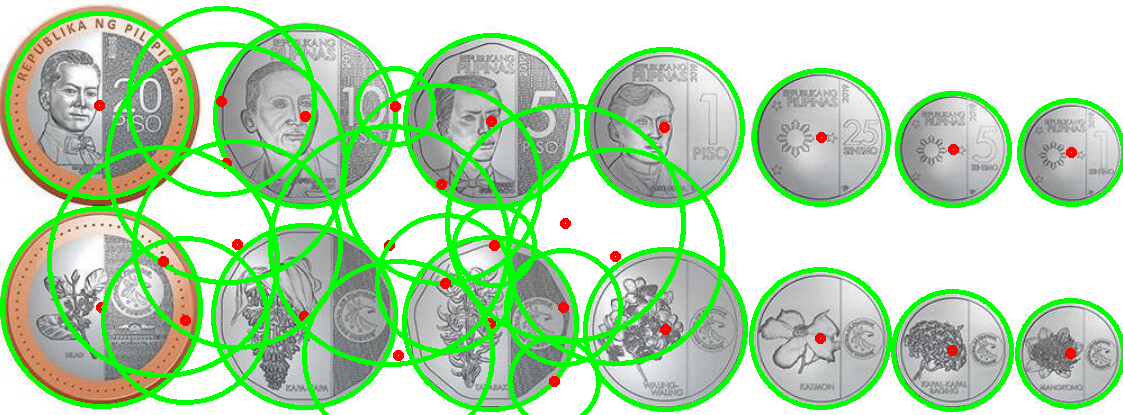

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

image_path = '/content/drive/MyDrive/ColabNotebooks/COINS.jpg'  # update if needed

count_with_line_detection(image_path)
count_with_circle_detection(image_path)


**EXPLANATION OF THE OUTPUT**


The circle detection algorithm successfully identified 29 coins in the image using the HoughCircles method. Each coin was marked with a green circle outlining its edge and a red dot at its center, confirming accurate detection. The preprocessing step with median blur helped reduce noise and sharpen circular features, improving detection reliability. This output demonstrates how computer vision can effectively isolate and count circular objects like coins regardless of their design or denomination.

## 5. Summary, Conclusions and Lessons Learned

**Summary of the Activity**

In this activity, I applied computer vision techniques using OpenCV to detect and count coins in an image. Both line detection (HoughLines) and circle detection (HoughCircles) were explored, with circle detection proving to be the most effective for identifying coins. The outputs included annotated images showing detected edges, lines, and circles, along with a printed count of coins.

**Personal Conclusions / Reflections**

I realized that while line detection is useful for identifying straight edges, it is not suitable for counting circular objects like coins. Circle detection, on the other hand, provided accurate results and demonstrated the importance of choosing the right algorithm for the right task. This activity showed me how preprocessing steps, such as blurring and edge detection, greatly influence the accuracy of detection.

**Lessons Learned**

From this module, I learned how the Hough Transform works in detecting geometric shapes such as lines and circles. I also understood the role of parameters like minimum radius, maximum radius, and sensitivity thresholds in fine‑tuning detection results. Most importantly, I gained practical experience in applying computer vision methods to real‑world problems, reinforcing the value of experimentation and parameter adjustment in achieving reliable outputs.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*